# Commodity Price Signal Backtester

This notebook builds a quantitative backtesting framework for commodity futures from scratch. We will analyze three major commodities:
- **Crude Oil (`CL=F`)**
- **Natural Gas (`NG=F`)**
- **Corn (`ZC=F`)**

We will implement two strategies: Momentum (Moving Average Crossover) and Mean-Reversion (Z-Score).

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 7)

## 1. Data Acquisition

We use `yfinance` to fetch historical daily price data for our commodity futures. The function `fetch_commodity_data` downloads the data and calculates daily returns.

In [2]:
def fetch_commodity_data(tickers, start_date, end_date):
    """
    Fetches historical daily price data for a list of tickers.
    
    Args:
        tickers (list or str): Ticker symbol(s) to fetch.
        start_date (str): Start date in 'YYYY-MM-DD' format.
        end_date (str): End date in 'YYYY-MM-DD' format.
        
    Returns:
        pd.DataFrame: A DataFrame containing the 'Close' prices for the tickers.
    """
    print(f"Fetching data for {tickers} from {start_date} to {end_date}...")
    df = yf.download(tickers, start=start_date, end=end_date)['Close']
    
    # If a single ticker is passed, yfinance returns a Series instead of a DataFrame.
    # We convert it to a DataFrame to maintain consistency.
    if isinstance(df, pd.Series):
        df = df.to_frame(name=tickers if isinstance(tickers, str) else tickers[0])
        
    # Drop any rows with entirely missing data (e.g. holidays)
    df.dropna(how='all', inplace=True)
    
    # Forward fill any missing intermediate data points
    df.ffill(inplace=True)
    
    print("Data fetching complete.")
    return df

In [3]:
# Let's test the data fetching for our 3 chosen commodities from 2020 to present
tickers = ['CL=F', 'NG=F', 'ZC=F']
df_prices = fetch_commodity_data(tickers, '2020-01-01', '2026-06-25')
df_prices.head()

Fetching data for ['CL=F', 'NG=F', 'ZC=F'] from 2020-01-01 to 2026-06-25...


[                       0%                       ]

[**********************67%*******                ]  2 of 3 completed

[*********************100%***********************]  3 of 3 completed

Data fetching complete.


Ticker,CL=F,NG=F,ZC=F
Date,,,
2020-01-02,61.180000,2.122,391.50
2020-01-03,63.049999,2.130,386.50
2020-01-06,63.270000,2.135,384.75
2020-01-07,62.700001,2.162,384.50
2020-01-08,59.610001,2.141,384.25


## 2. Momentum Strategy

The momentum strategy aims to ride trends. We will use a classic **Moving Average Crossover** system.
- **Fast Moving Average (e.g. 20-day)**: Responds quickly to price changes.
- **Slow Moving Average (e.g. 50-day)**: Represents the longer-term trend.

**Signal Logic**:
- **Buy (1)**: When the Fast MA is above the Slow MA.
- **Sell/Short (-1)**: When the Fast MA is below the Slow MA.

In [4]:
def calculate_momentum_signal(prices, fast_window=20, slow_window=50):
    """
    Calculates momentum trading signals based on Moving Average Crossover.
    
    Args:
        prices (pd.Series or pd.DataFrame): Historical prices.
        fast_window (int): Lookback period for the fast moving average.
        slow_window (int): Lookback period for the slow moving average.
        
    Returns:
        pd.DataFrame: A DataFrame containing the trading signals (1 for long, -1 for short).
    """
    # Calculate simple moving averages
    fast_ma = prices.rolling(window=fast_window).mean()
    slow_ma = prices.rolling(window=slow_window).mean()
    
    # Generate signals: 1 if fast_ma > slow_ma, else -1
    signals = np.where(fast_ma > slow_ma, 1.0, -1.0)
    
    # Convert numpy array back to pandas DataFrame/Series
    if isinstance(prices, pd.DataFrame):
        signals = pd.DataFrame(signals, index=prices.index, columns=prices.columns)
    else:
        signals = pd.Series(signals, index=prices.index, name='Signal')
        
    # Set the initial warm-up period to 0 (no position)
    signals.iloc[:slow_window] = 0.0
    
    return signals

In [5]:
# Test the momentum signal generator
momentum_signals = calculate_momentum_signal(df_prices, fast_window=20, slow_window=50)
momentum_signals.tail()

Ticker,CL=F,NG=F,ZC=F
Date,,,
2026-06-17,-1.0,1.0,-1.0
2026-06-18,-1.0,1.0,-1.0
2026-06-22,-1.0,1.0,-1.0
2026-06-23,-1.0,1.0,-1.0
2026-06-24,-1.0,1.0,-1.0


## 3. Mean-Reversion Strategy

The mean-reversion strategy assumes that prices will revert to their historical average. We will use a **Z-Score** approach (similar to Bollinger Bands).
- **Z-Score**: Represents how many standard deviations the current price is from its rolling mean.
- **Overbought**: When Z-Score > 2.0 (Price is too high, expect a drop -> Sell/Short).
- **Oversold**: When Z-Score < -2.0 (Price is too low, expect a bounce -> Buy/Long).

In [6]:
def calculate_mean_reversion_signal(prices, window=20, z_threshold=2.0):
    """
    Calculates mean-reversion trading signals using rolling Z-Scores.
    
    Args:
        prices (pd.Series or pd.DataFrame): Historical prices.
        window (int): Lookback period for calculating rolling mean and std dev.
        z_threshold (float): Z-score threshold for generating signals.
        
    Returns:
        pd.DataFrame: A DataFrame containing the trading signals (1 for long, -1 for short, 0 for neutral).
    """
    # Calculate rolling mean and standard deviation
    rolling_mean = prices.rolling(window=window).mean()
    rolling_std = prices.rolling(window=window).std()
    
    # Calculate Z-Score
    z_score = (prices - rolling_mean) / rolling_std
    
    # Generate signals: 
    # Long (1) when z_score < -z_threshold
    # Short (-1) when z_score > z_threshold
    # Neutral (0) otherwise
    signals = np.zeros_like(prices)
    signals = np.where(z_score < -z_threshold, 1.0, signals)
    signals = np.where(z_score > z_threshold, -1.0, signals)
    
    # Convert numpy array back to pandas DataFrame/Series
    if isinstance(prices, pd.DataFrame):
        signals = pd.DataFrame(signals, index=prices.index, columns=prices.columns)
    else:
        signals = pd.Series(signals, index=prices.index, name='Signal')
        
    # Fill NaN values (which occur during the warmup window) with 0.0
    signals = signals.fillna(0.0)
    
    return signals

In [7]:
# Test the mean-reversion signal generator
mr_signals = calculate_mean_reversion_signal(df_prices, window=20, z_threshold=2.0)
mr_signals.tail()

Ticker,CL=F,NG=F,ZC=F
Date,,,
2026-06-17,1.0,0.0,0.0
2026-06-18,0.0,0.0,0.0
2026-06-22,0.0,0.0,0.0
2026-06-23,0.0,0.0,0.0
2026-06-24,0.0,0.0,0.0


## 4. Backtesting Engine

The backtesting engine takes the historical prices and the generated trading signals to calculate daily strategy returns and cumulative portfolio value.

**Critical concept**: We shift the signals by 1 day forward. This is to avoid **look-ahead bias**. If a signal is calculated using the closing price of day `t`, we can only enter the trade on day `t+1` and earn the return of day `t+1`.

In [8]:
def run_backtest(prices, signals):
    """
    Simulates trading based on signals and calculates daily strategy returns.
    
    Args:
        prices (pd.Series or pd.DataFrame): Historical prices.
        signals (pd.Series or pd.DataFrame): Trading signals (1, 0, -1).
        
    Returns:
        tuple: (daily_strategy_returns, cumulative_strategy_returns)
    """
    # Calculate daily percent change (returns) of the underlying asset
    asset_returns = prices.pct_change()
    
    # Shift signals by 1 day to avoid look-ahead bias
    shifted_signals = signals.shift(1)
    
    # Calculate strategy daily returns (Signal * Asset Return)
    strategy_returns = shifted_signals * asset_returns
    
    # Fill any NaN returns resulting from shifts or missing data with 0
    strategy_returns = strategy_returns.fillna(0.0)
    
    # Calculate cumulative returns using simple compounding
    cumulative_returns = (1 + strategy_returns).cumprod()
    
    return strategy_returns, cumulative_returns

In [9]:
# Run backtest for Momentum
mom_daily_returns, mom_cum_returns = run_backtest(df_prices, momentum_signals)
# Run backtest for Mean Reversion
mr_daily_returns, mr_cum_returns = run_backtest(df_prices, mr_signals)

# Display final cumulative returns for Momentum
print("Momentum Strategy Final Cumulative Returns:")
print(mom_cum_returns.iloc[-1])

Momentum Strategy Final Cumulative Returns:
Ticker
CL=F    2.270621
NG=F    0.430964
ZC=F    1.740488
Name: 2026-06-24 00:00:00, dtype: float64


## 5. Performance Analytics

To evaluate how good our strategies are, we calculate three key metrics:
1. **Sharpe Ratio**: Measures the risk-adjusted return (Return per unit of risk). Higher is better.
2. **Maximum Drawdown**: Measures the largest peak-to-trough drop in portfolio value. Measures worst-case risk.
3. **Rolling Volatility**: Measures how the risk changes over time (standard deviation of returns over a moving window).

In [10]:
def calculate_sharpe_ratio(returns, risk_free_rate=0.0, periods_per_year=252):
    """
    Calculates the annualized Sharpe Ratio.
    
    Args:
        returns (pd.Series or pd.DataFrame): Daily strategy returns.
        risk_free_rate (float): Annual risk-free rate.
        periods_per_year (int): Number of trading days in a year.
        
    Returns:
        float or pd.Series: Annualized Sharpe Ratio.
    """
    daily_rf = risk_free_rate / periods_per_year
    excess_returns = returns - daily_rf
    sharpe = (excess_returns.mean() / excess_returns.std()) * np.sqrt(periods_per_year)
    return sharpe

def calculate_maximum_drawdown(cumulative_returns):
    """
    Calculates the maximum drawdown of a strategy.
    
    Args:
        cumulative_returns (pd.Series or pd.DataFrame): Cumulative strategy returns.
        
    Returns:
        float or pd.Series: Maximum drawdown percentage.
    """
    running_max = cumulative_returns.cummax()
    drawdown = (running_max - cumulative_returns) / running_max
    return drawdown.max()

def calculate_rolling_volatility(returns, window=252):
    """
    Calculates annualized rolling volatility.
    
    Args:
        returns (pd.Series or pd.DataFrame): Daily strategy returns.
        window (int): Rolling window in days.
        
    Returns:
        pd.DataFrame or pd.Series: Rolling annualized volatility.
    """
    rolling_vol = returns.rolling(window=window).std() * np.sqrt(252)
    return rolling_vol

In [11]:
# Calculate metrics for the strategies
print("--- Momentum Strategy Metrics ---")
print(f"Sharpe Ratio:\n{calculate_sharpe_ratio(mom_daily_returns)}\n")
print(f"Max Drawdown:\n{calculate_maximum_drawdown(mom_cum_returns)}\n")

print("--- Mean-Reversion Strategy Metrics ---")
print(f"Sharpe Ratio:\n{calculate_sharpe_ratio(mr_daily_returns)}\n")
print(f"Max Drawdown:\n{calculate_maximum_drawdown(mr_cum_returns)}\n")

--- Momentum Strategy Metrics ---
Sharpe Ratio:
Ticker
CL=F    0.421238
NG=F    0.234002
ZC=F    0.453182
dtype: float64

Max Drawdown:
Ticker
CL=F    0.918776
NG=F    0.847077
ZC=F    0.516888
dtype: float64

--- Mean-Reversion Strategy Metrics ---
Sharpe Ratio:
Ticker
CL=F   -0.365489
NG=F    0.893015
ZC=F   -0.537181
dtype: float64

Max Drawdown:
Ticker
CL=F    1.288124
NG=F    0.453172
ZC=F    0.433234
dtype: float64



## 6. Visualization

Visualizing the performance is crucial for understanding the strategy's behavior across different market regimes.
We will plot:
1. **Equity Curve**: The cumulative portfolio return over time.
2. **Underwater Chart (Drawdown)**: Shows the depth and duration of drawdowns.
3. **Rolling Volatility**: Shows the dynamic risk of the strategy.

In [12]:
def plot_equity_curve(cumulative_returns, title="Strategy Equity Curve"):
    """
    Plots the cumulative returns (Equity Curve).
    
    Args:
        cumulative_returns (pd.Series or pd.DataFrame): Cumulative returns.
        title (str): Plot title.
    """
    plt.figure()
    cumulative_returns.plot(lw=2)
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return (1.0 = Base)')
    plt.axhline(1.0, color='red', linestyle='--', alpha=0.7)
    # plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

def plot_drawdown(cumulative_returns, title="Strategy Drawdown"):
    """
    Plots the underwater (drawdown) chart.
    
    Args:
        cumulative_returns (pd.Series or pd.DataFrame): Cumulative returns.
        title (str): Plot title.
    """
    running_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - running_max) / running_max
    
    plt.figure()
    drawdown.plot(lw=1.5, alpha=0.8)
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Drawdown')
    # Use 0 as the top line for the fill
    # plt.fill_between(drawdown.index, drawdown.min().min() if hasattr(drawdown.min(), 'min') else drawdown.min(), 0, alpha=0.1)
    plt.tight_layout()
    plt.show()

def plot_rolling_volatility(returns, window=252, title="Rolling Annualized Volatility"):
    """
    Plots the rolling volatility.
    
    Args:
        returns (pd.Series or pd.DataFrame): Daily returns.
        window (int): Rolling window length.
        title (str): Plot title.
    """
    rolling_vol = calculate_rolling_volatility(returns, window)
    
    plt.figure()
    rolling_vol.plot(lw=1.5)
    plt.title(title + f" ({window}-Day)")
    plt.xlabel('Date')
    plt.ylabel('Volatility')
    plt.tight_layout()
    plt.show()

=== Visualizing Momentum Strategy for CL=F ===


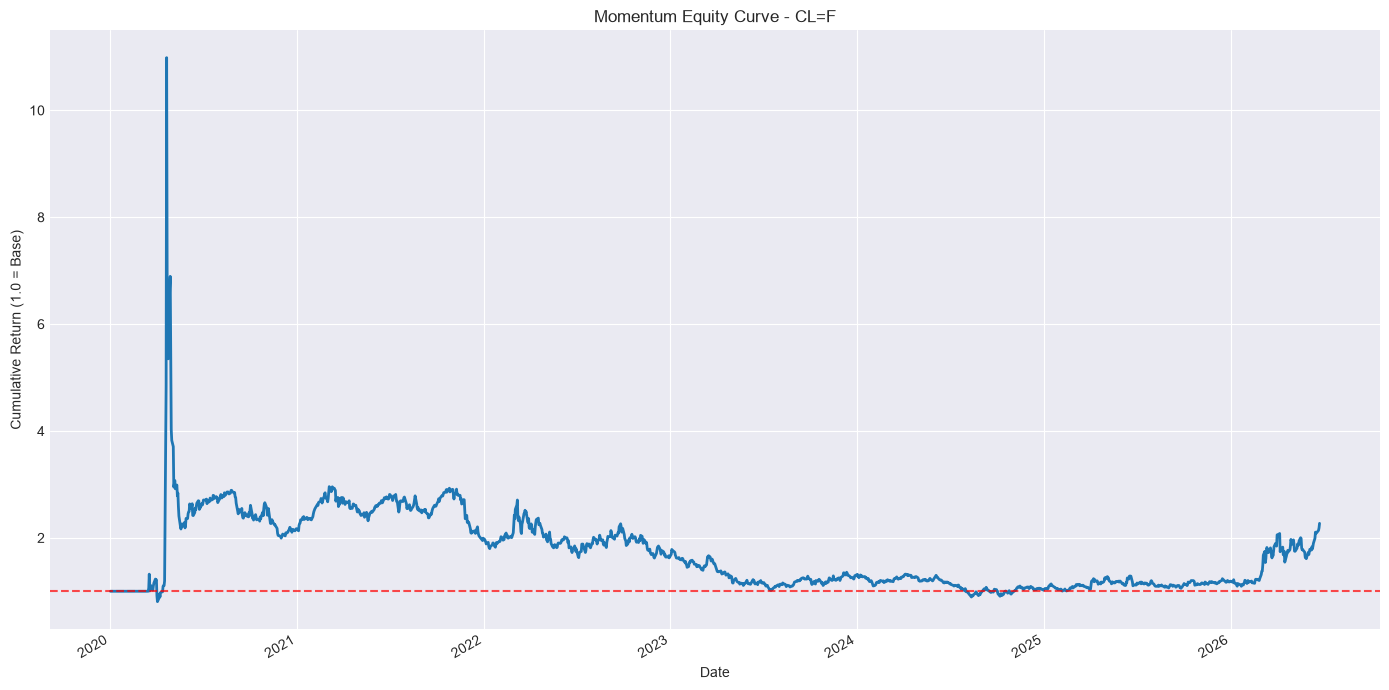

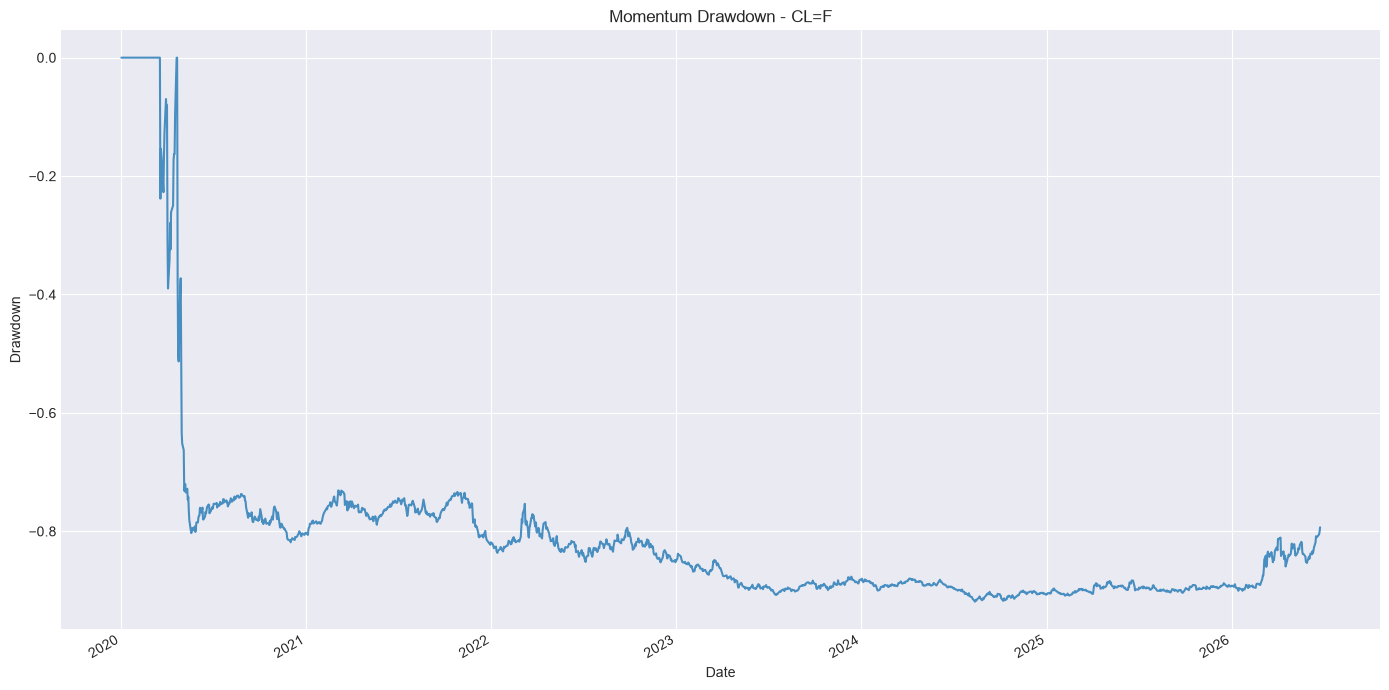

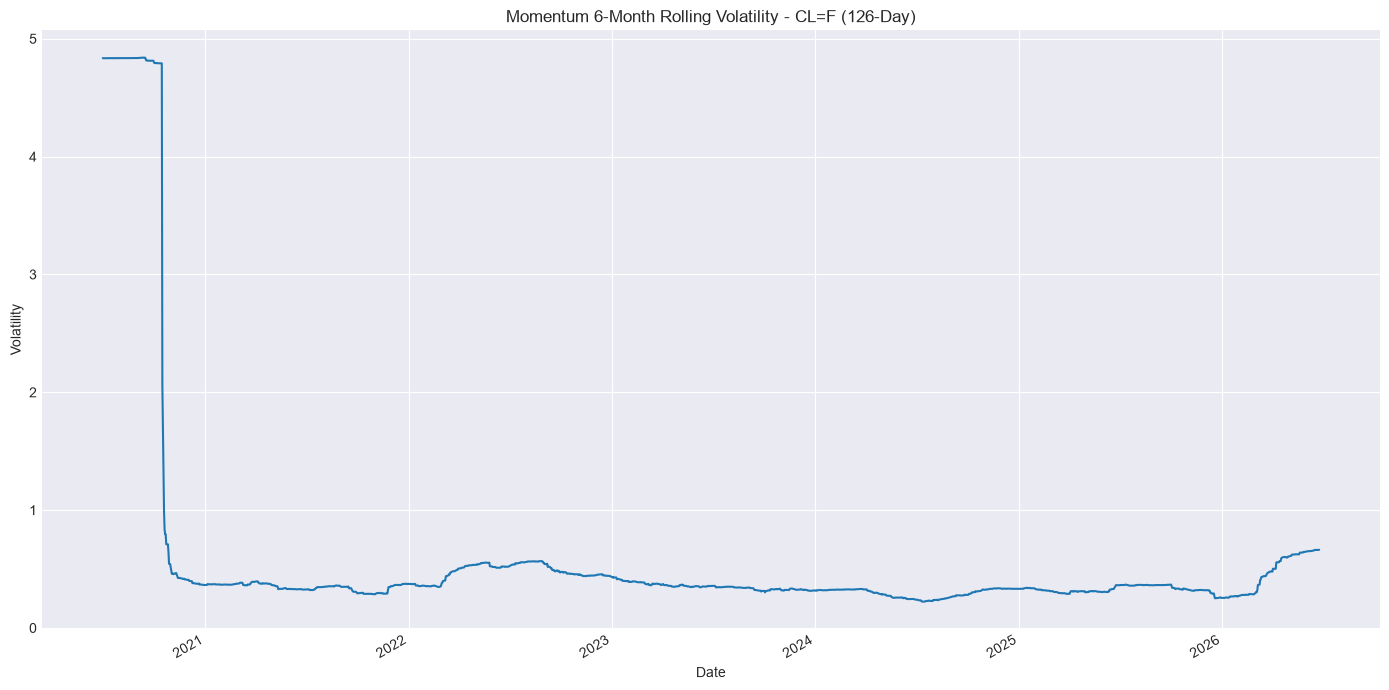

In [13]:
# Plot results for Crude Oil (CL=F)
commodity = 'CL=F'

print(f"=== Visualizing Momentum Strategy for {commodity} ===")
plot_equity_curve(mom_cum_returns[commodity], title=f"Momentum Equity Curve - {commodity}")
plot_drawdown(mom_cum_returns[commodity], title=f"Momentum Drawdown - {commodity}")
plot_rolling_volatility(mom_daily_returns[commodity], window=126, title=f"Momentum 6-Month Rolling Volatility - {commodity}")

## 7. Transaction Costs

Real-world trading involves friction: commissions and bid-ask slippage. 
Every time our signal changes, we incur a cost. This is especially important for mean-reversion strategies which may trade frequently.

In [14]:
def apply_transaction_costs(strategy_returns, signals, cost_per_trade=0.001):
    """
    Deducts transaction costs from strategy returns when the position changes.
    
    Args:
        strategy_returns (pd.Series or pd.DataFrame): Daily strategy returns.
        signals (pd.Series or pd.DataFrame): Trading signals (1, 0, -1).
        cost_per_trade (float): Cost incurred per trade as a percentage.
        
    Returns:
        tuple: (returns_after_costs, cumulative_returns_after_costs)
    """
    # A trade occurs when the signal changes from the previous day
    signal_diff = signals.diff().abs()
    
    # Costs are applied on the days the signal changed
    costs = signal_diff * cost_per_trade
    costs = costs.fillna(0.0)
    
    # Subtract costs from the strategy returns
    returns_after_costs = strategy_returns - costs
    cumulative_returns_after_costs = (1 + returns_after_costs).cumprod()
    
    return returns_after_costs, cumulative_returns_after_costs

Applying 0.1% transaction cost per trade to Momentum Strategy...


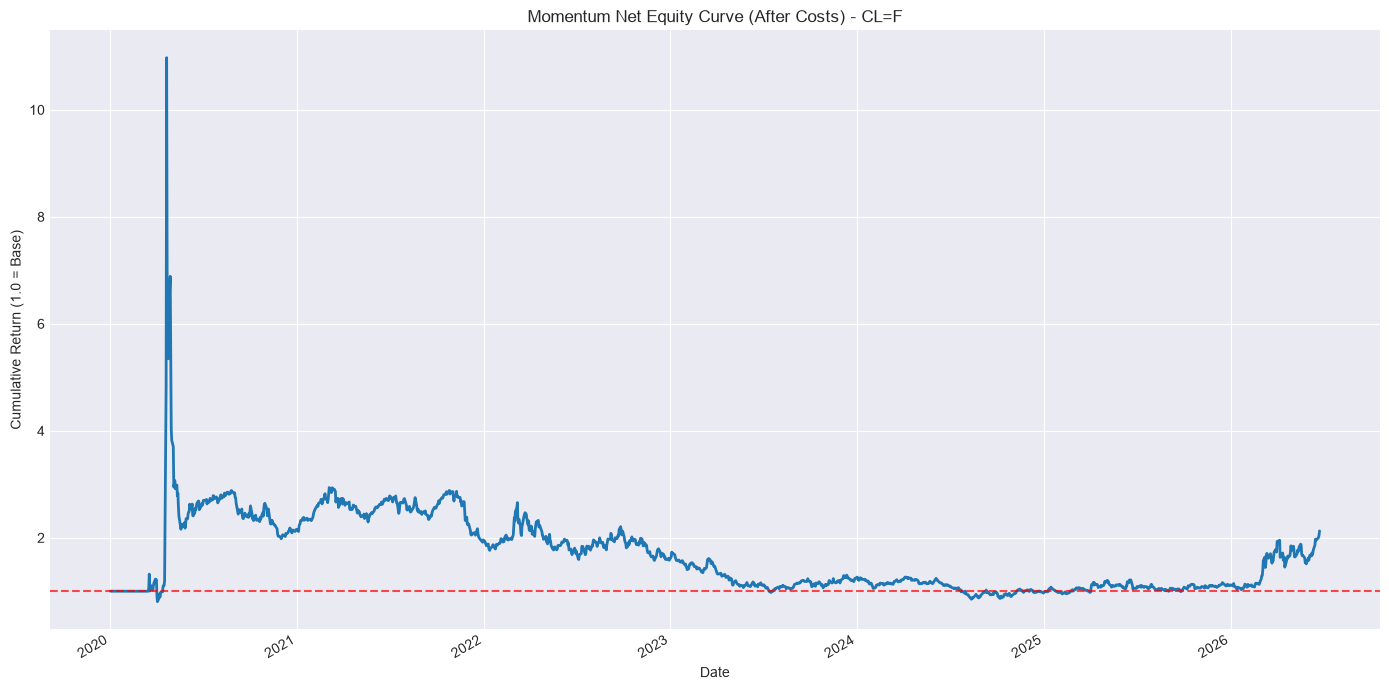

In [15]:
# Test transaction costs on Momentum
print("Applying 0.1% transaction cost per trade to Momentum Strategy...")
net_daily, net_cum = apply_transaction_costs(mom_daily_returns, momentum_signals, cost_per_trade=0.001)

# Re-plot the net equity curve
plot_equity_curve(net_cum[commodity], title=f"Momentum Net Equity Curve (After Costs) - {commodity}")